## Coherence Score

This notebook evaluates topic numbers ranging from 1-20 to find the optimal number of topics to be used for LDA topic modelling.



In [1]:
!pip install -r ../requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 6.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

In [3]:
# Data Loading

CS_FILE            = Path("../data/skills/cs_special_course_skills.jsonl")
DATA_SCIENCE_FILE  = Path("../data/skills/data_science_jobs_skills.jsonl")

for f in [CS_FILE, DATA_SCIENCE_FILE]:
    if not f.exists():
        raise FileNotFoundError(f"{f} not found.")

cs_df            = pd.read_json(CS_FILE, lines=True)
data_science_df  = pd.read_json(DATA_SCIENCE_FILE, lines=True)

In [4]:
# Function to normalize multi-word skills by replacing spaces with underscores

def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(skill).strip().replace(" ", "_") for skill in skills if str(skill).strip()]

cs_df["skills"]            = cs_df["skills"].apply(normalize_multiword_skills)
data_science_df["skills"]  = data_science_df["skills"].apply(normalize_multiword_skills)

cs_texts            = cs_df["skills"].tolist()
data_science_texts  = data_science_df["skills"].tolist()

In [5]:
# Function to remove thematic area names from the skill lists to prevent them from dominating the topic modeling results
def clean_tokens(tokens):
    return [
        t for t in tokens
        if t not in {"computer_science", "information_technology"}
    ]

cs_texts            = [clean_tokens(t) for t in cs_texts]
data_science_texts  = [clean_tokens(t) for t in data_science_texts]

In [6]:
# Verifying the cleaned DataFrames

cs_df.head()
data_science_df.head()

,source,region,job_category,search_term,job_title,skills
0,workopolis,Canada,AI,Data Scientist,"Staff Data Scientist, Firefox","[causal_inference, code_review, data_analysis,..."
1,workopolis,Canada,AI,Data Scientist,Junior Data Scientist,"[data_model, machine_learning, algorithm, bank..."
2,workopolis,Canada,AI,Data Scientist,Data Specialist - 26327D,"[analytical_skill, benefits_employee, business..."
3,workopolis,Canada,AI,Data Scientist,Data Scientist,"[cloud_computing, critical_thinking, data_inte..."
4,workopolis,Canada,AI,Data Scientist,"Data Analytics Partner, People Analytics","[business_intelligence, business_requirement, ..."


In [7]:
# Function to evaluate coherence scores for a range of topic numbers and return the best model and its details
def evaluate_coherence(skills, start=1, limit=20, step=1, no_below=1, no_above=0.8):
    dictionary = Dictionary(skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(skill) for skill in skills]

    model_list = []
    coherence_values = []
    topic_range = list(range(start, limit, step))

    for num_topics in topic_range:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            iterations=100
        )

        coherence_model = CoherenceModel(
            model=model,
            texts=skills,
            dictionary=dictionary,
            coherence="c_v"
        )

        model_list.append(model)
        coherence_values.append(coherence_model.get_coherence())

    best_index = coherence_values.index(max(coherence_values))

    return {
        "dictionary": dictionary,
        "corpus": corpus,
        "topic_range": topic_range,
        "model_list": model_list,
        "coherence_values": coherence_values,
        "best_model": model_list[best_index],
        "best_num_topics": topic_range[best_index],
        "best_coherence": coherence_values[best_index],
    }


# Computer Science Course Topic Evaluation


Computer Science Course Coherence Scores: 
Number of Topics: 1, Coherence Score: 0.2567
Number of Topics: 2, Coherence Score: 0.3185
Number of Topics: 3, Coherence Score: 0.3569
Number of Topics: 4, Coherence Score: 0.4119
Number of Topics: 5, Coherence Score: 0.4132
Number of Topics: 6, Coherence Score: 0.3509
Number of Topics: 7, Coherence Score: 0.4814
Number of Topics: 8, Coherence Score: 0.5461
Number of Topics: 9, Coherence Score: 0.5113
Number of Topics: 10, Coherence Score: 0.5581
Number of Topics: 11, Coherence Score: 0.6452
Number of Topics: 12, Coherence Score: 0.6365
Number of Topics: 13, Coherence Score: 0.6889
Number of Topics: 14, Coherence Score: 0.7827
Number of Topics: 15, Coherence Score: 0.7928
Number of Topics: 16, Coherence Score: 0.6953
Number of Topics: 17, Coherence Score: 0.7583
Number of Topics: 18, Coherence Score: 0.6911
Number of Topics: 19, Coherence Score: 0.7236


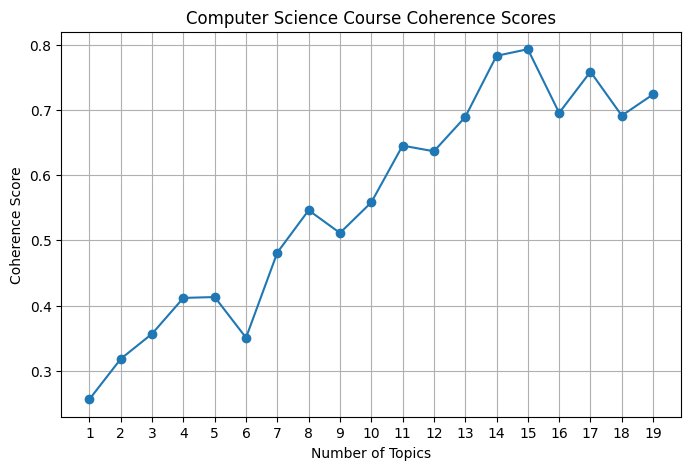

Optimal Number of Topics: 15
Coherence Score: 0.7928

Top 10 Words per Topic 15: 

Topic: 0: 0.001*"client_application" + 0.001*"mobility_management" + 0.001*"tablet" + 0.001*"networks_data" + 0.001*"communication_system" + 0.001*"statistics" + 0.001*"abstraction" + 0.001*"wireless_fixed" + 0.001*"lte" + 0.001*"parallelism_computational" + 0.001*"sensor_network" + 0.001*"network_architecture" + 0.001*"network_management" + 0.001*"remote_procedure" + 0.001*"communications" + 0.001*"personal_area_network" + 0.001*"communication_wireless" + 0.001*"performance_metric" + 0.001*"resource_allocation" + 0.001*"mobile_ip"

Topic: 1: 0.008*"analytics" + 0.008*"big_data" + 0.008*"machine_learn" + 0.008*"system_design" + 0.008*"teamwork" + 0.008*"software_engineering" + 0.004*"emerge_technology" + 0.004*"distribute_memory" + 0.004*"big_datum" + 0.004*"research" + 0.004*"technical_documentation" + 0.004*"programming_environment" + 0.004*"scalability" + 0.004*"data_cleaning" + 0.004*"data_ethics" + 

In [8]:
cs_results = evaluate_coherence(cs_texts, start=1, limit=20, step=1)

print("Computer Science Course Coherence Scores: ")
for k, score in zip(cs_results["topic_range"], cs_results["coherence_values"]):
    print(f"Number of Topics: {k}, Coherence Score: {score:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(cs_results["topic_range"], cs_results["coherence_values"], marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Computer Science Course Coherence Scores")
plt.xticks(cs_results["topic_range"])
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {cs_results['best_num_topics']}")
print(f"Coherence Score: {cs_results['best_coherence']:.4f}")
topics = cs_results["best_model"].print_topics(num_words=20)
print(f"\nTop 10 Words per Topic {cs_results['best_num_topics']}: ")
for topic_num, topic_words in topics:
    print(f"\nTopic: {topic_num}: {topic_words}")


# Data Science Jobs Topic Evaluation

Data Science Jobs Coherence Scores: 
Number of Topics: 1, Coherence Score: 0.3621
Number of Topics: 2, Coherence Score: 0.3600
Number of Topics: 3, Coherence Score: 0.3355
Number of Topics: 4, Coherence Score: 0.3207
Number of Topics: 5, Coherence Score: 0.3254
Number of Topics: 6, Coherence Score: 0.4324
Number of Topics: 7, Coherence Score: 0.4011
Number of Topics: 8, Coherence Score: 0.3722
Number of Topics: 9, Coherence Score: 0.4328
Number of Topics: 10, Coherence Score: 0.4049
Number of Topics: 11, Coherence Score: 0.4024
Number of Topics: 12, Coherence Score: 0.3976
Number of Topics: 13, Coherence Score: 0.4539
Number of Topics: 14, Coherence Score: 0.4358
Number of Topics: 15, Coherence Score: 0.4972
Number of Topics: 16, Coherence Score: 0.4785
Number of Topics: 17, Coherence Score: 0.4724
Number of Topics: 18, Coherence Score: 0.4550
Number of Topics: 19, Coherence Score: 0.4492


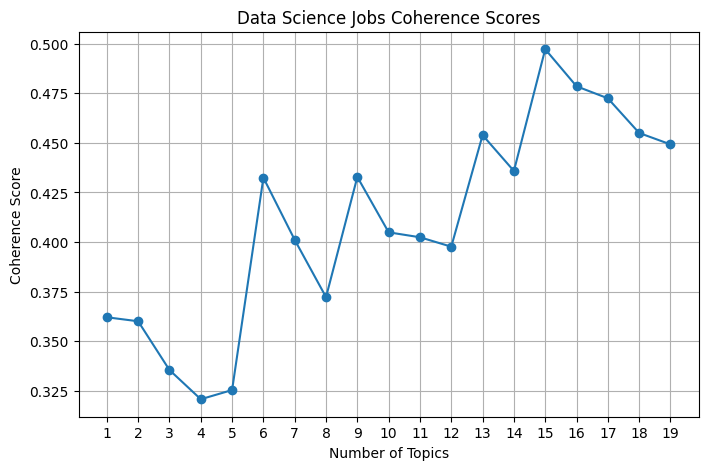

Optimal Number of Topics: 15
Coherence Score: 0.4972

Top 10 Words per Topic 15: 

Topic: 0: 0.071*"github" + 0.069*"stakeholder_management" + 0.043*"management" + 0.043*"code_review" + 0.043*"sprint_planning" + 0.043*"prototype" + 0.030*"writing" + 0.029*"language_model" + 0.029*"creativity" + 0.029*"business_case"

Topic: 1: 0.082*"python" + 0.067*"machine_learning" + 0.067*"sql" + 0.030*"data_analysis" + 0.030*"forecasting" + 0.030*"statistics" + 0.030*"data_visualisation" + 0.029*"writing" + 0.022*"artificial_intelligence" + 0.022*"financial_service"

Topic: 2: 0.052*"customer_experience" + 0.052*"research_experience" + 0.052*"data_analysis" + 0.052*"social_science" + 0.052*"curiosity" + 0.052*"accountability" + 0.052*"process_improvement" + 0.052*"microsoft_excel" + 0.052*"storytelling" + 0.052*"quality_auditing"

Topic: 3: 0.064*"machine_learning" + 0.062*"python" + 0.049*"sql" + 0.044*"sales" + 0.043*"demand_forecasting" + 0.035*"statistical_modelling" + 0.034*"statistics" + 0.0

In [9]:
data_science_results = evaluate_coherence(data_science_texts, start=1, limit=20, step=1)

print("Data Science Jobs Coherence Scores: ")
for k, score in zip(data_science_results["topic_range"], data_science_results["coherence_values"]):
    print(f"Number of Topics: {k}, Coherence Score: {score:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(data_science_results["topic_range"], data_science_results["coherence_values"], marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Data Science Jobs Coherence Scores")
plt.xticks(data_science_results["topic_range"])
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {data_science_results['best_num_topics']}")
print(f"Coherence Score: {data_science_results['best_coherence']:.4f}")
topics = data_science_results["best_model"].print_topics(num_words=10)
print(f"\nTop 10 Words per Topic {data_science_results['best_num_topics']}: ")
for topic_num, topic_words in topics:
    print(f"\nTopic: {topic_num}: {topic_words}")